###  Feature Importance Analysis

In this notebook, we analyze which features the calibrated Random Forest model relies on when making predictions. This helps evaluate whether the model is learning meaningful relationships from the data.

In [11]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
model = joblib.load("calibrated_rf.pkl")

X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

In [15]:
feature_importance = model.calibrated_classifiers_[0].estimator.feature_importances_

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": feature_importance
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df

,feature,importance
1,Sex,0.367404
3,Fare_log,0.228113
2,Age,0.187571
0,Pclass,0.115465
4,FamilySize,0.082050
5,IsAlone,0.019397


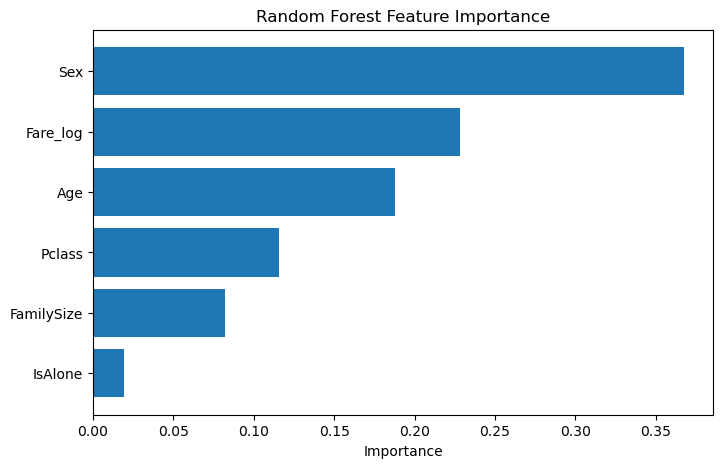

In [16]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

### Feature importance analysis shows that the model primarily relies on meaningful predictors such as passenger sex, fare, age, and passenger class. The dominance of the "Sex" feature aligns with the well-known survival pattern in the Titanic disaster, where female passengers had significantly higher survival rates. Similarly, fare and passenger class capture socioeconomic status, which influenced access to lifeboats. The consistency between the model's importance ranking and historical knowledge indicates that the model is learning realistic patterns rather than relying on spurious correlations.